<a href="https://colab.research.google.com/github/sromerar/omics-tutorials/blob/main/01_atlas_getting_started.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ATLAS: Getting Started

Annotated reproduction of the official ATLAS getting-started tutorial for multimodal single-cell trajectory inference.

## 1. Environment setup

ATLAS is installed from PyPI using the `atlas-smilies` package.

Because Google Colab comes with a preconfigured Python environment, installing ATLAS may update existing dependencies. I therefore verify the core package imports and record their versions before proceeding with the analysis.

### Environment check

Before installing ATLAS, I record the base Google Colab environment. This is useful for diagnosing dependency conflicts and makes the computational environment more transparent and reproducible.

In [1]:
!pip install "numpy==2.0.2" "pandas==2.2.3" "atlas-smilies==1.0.0"

INFO: pip is looking at multiple versions of anndata to determine which version is compatible with other requirements. This could take a while.
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of scanpy to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.0/245.0 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.5/64.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 99.7 MB/s eta 0:00

### Verify the installation

Confirm that ATLAS and the core single-cell dependencies import successfully, and record their versions for reproducibility.

In [2]:
import atlas
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np

print("ATLAS imported successfully")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Scanpy:", sc.__version__)
print("muon:", mu.__version__)

ATLAS imported successfully
NumPy: 2.0.2
pandas: 2.2.3
Scanpy: 1.12
muon: 0.1.9


### Install ATAC fragment-file dependency

The official ATLAS workflow uses `pysam` when working with indexed scATAC-seq fragment files. I install and verify it separately because it is not included as a core `atlas-smilies` dependency.

In [3]:
!pip install pysam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 11.1 MB/s eta 0:00:00


In [4]:
import pysam

print("pysam:", pysam.__version__)

pysam: 0.24.0


## 2. Download the tutorial data

The official ATLAS getting-started tutorial uses the 10x Genomics E18 mouse brain multiome dataset, which contains paired gene-expression and chromatin-accessibility measurements from the same cells.

I also download the cell-type annotations used in the tutorial from the MultiVelo repository.

In [5]:
!mkdir -p data && cd data \
    && wget -q https://raw.githubusercontent.com/welch-lab/MultiVelo/main/Examples/cell_annotations.tsv \
    && curl -L -O https://cf.10xgenomics.com/samples/cell-arc/1.0.0/e18_mouse_brain_fresh_5k/e18_mouse_brain_fresh_5k_filtered_feature_bc_matrix.tar.gz \
    && tar -xzf e18_mouse_brain_fresh_5k_filtered_feature_bc_matrix.tar.gz \
    && curl -L -O https://cf.10xgenomics.com/samples/cell-arc/1.0.0/e18_mouse_brain_fresh_5k/e18_mouse_brain_fresh_5k_atac_fragments.tsv.gz \
    && curl -L -O https://cf.10xgenomics.com/samples/cell-arc/1.0.0/e18_mouse_brain_fresh_5k/e18_mouse_brain_fresh_5k_atac_fragments.tsv.gz.tbi

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  194M  100  194M    0     0  83.2M      0  0:00:02  0:00:02 --:--:-- 83.1M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  987M  100  987M    0     0  62.9M      0  0:00:15  0:00:15 --:--:--  145M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  709k  100  709k    0     0  1015k      0 --:--:-- --:--:-- --:--:-- 1016k


### Verify downloaded files

I inspect the downloaded data directory to confirm that the 10x feature-barcode matrix, ATAC fragments file, fragment index, and cell-type annotation file are present before proceeding.

In [6]:
!ls -lh data

total 1.2G
-rw-r--r-- 1 root root 133K Aug 20 13:37 cell_annotations.tsv
-rw-r--r-- 1 root root 988M Aug 20 13:38 e18_mouse_brain_fresh_5k_atac_fragments.tsv.gz
-rw-r--r-- 1 root root 710K Aug 20 13:38 e18_mouse_brain_fresh_5k_atac_fragments.tsv.gz.tbi
-rw-r--r-- 1 root root 195M Aug 20 13:37 e18_mouse_brain_fresh_5k_filtered_feature_bc_matrix.tar.gz
drwxr-xr-x 2 5233 5000 4.0K Sep  5  2020 filtered_feature_bc_matrix


## 3. Load packages and define file paths

I import the libraries used throughout the ATLAS workflow, set a random seed for reproducibility, and define paths to the downloaded 10x multiome data and cell-type annotations.

In [7]:
import os
import atlas
import scanpy as sc
import muon as mu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from muon import MuData
from anndata import AnnData
from scipy.stats import median_abs_deviation

seed = 42
np.random.seed(seed)

data_path = os.path.join(os.getcwd(), "data")
annotation_path = os.path.join(data_path, "cell_annotations.tsv")
ffbcm = os.path.join(data_path, "filtered_feature_bc_matrix")

print("Data path:", data_path)
print("Annotations:", annotation_path)
print("10x matrix:", ffbcm)

Data path: /content/data
Annotations: /content/data/cell_annotations.tsv
10x matrix: /content/data/filtered_feature_bc_matrix


## 4. Load the multimodal 10x data

The 10x feature-barcode matrix contains both gene-expression and chromatin-accessibility features measured from the same cells. I load the complete matrix and then separate it into RNA and ATAC `AnnData` objects using the feature annotations provided by 10x Genomics.

In [8]:
data = sc.read_10x_mtx(
    ffbcm,
    var_names="gene_symbols",
    gex_only=False
)

rna = data[:, data.var["feature_types"] == "Gene Expression"].copy()
atac = data[:, data.var["feature_types"] != "Gene Expression"].copy()

print("Combined matrix:", data.shape)
print("RNA:", rna.shape)
print("ATAC:", atac.shape)
print("\nFeature types:")
print(data.var["feature_types"].value_counts())

Combined matrix: (4881, 176722)
RNA: (4881, 32285)
ATAC: (4881, 144437)

Feature types:
feature_types
Peaks              144437
Gene Expression     32285
Name: count, dtype: int64


### Inspect feature metadata

ATLAS requires genomic coordinates for genes when calculating gene-activity scores from scATAC-seq fragments. The 10x `features.tsv.gz` file contains the feature annotations used to construct these coordinates.

In [9]:
features_path = os.path.join(ffbcm, "features.tsv.gz")

features = pd.read_csv(
    features_path,
    sep="\t",
    header=None
)

print("Feature metadata shape:", features.shape)
features.head()

Feature metadata shape: (176722, 6)


,0,1,2,3,4,5
0,ENSMUSG00000051951,Xkr4,Gene Expression,chr1,3671497,3671498
1,ENSMUSG00000089699,Gm1992,Gene Expression,chr1,3466586,3466587
2,ENSMUSG00000102331,Gm19938,Gene Expression,chr1,3658903,3658904
3,ENSMUSG00000102343,Gm37381,Gene Expression,chr1,3985983,3986215
4,ENSMUSG00000025900,Rp1,Gene Expression,chr1,4360313,4409241


### Construct gene genomic coordinates

ATLAS computes gene-activity scores by linking scATAC-seq fragments to genes. This requires genomic coordinates for each gene. I extract these coordinates from the 10x feature metadata and retain genes located on the standard mouse chromosomes.

In [10]:
features.columns = [
    "gene_id",
    "symbol",
    "feature_type",
    "Chromosome",
    "Start",
    "End",
]

gene_coordinates = (
    features.loc[
        features["feature_type"] == "Gene Expression",
        ["symbol", "Chromosome", "Start", "End"]
    ]
    .set_index("symbol")
)

standard_chromosomes = (
    [f"chr{i}" for i in range(1, 20)]
    + ["chrX", "chrY"]
)

gene_coordinates = gene_coordinates[
    gene_coordinates["Chromosome"].isin(standard_chromosomes)
]

print("Genes with genomic coordinates:", gene_coordinates.shape[0])
gene_coordinates.head()

Genes with genomic coordinates: 32195


,Chromosome,Start,End
symbol,,,
Xkr4,chr1,3671497,3671498
Gm1992,chr1,3466586,3466587
Gm19938,chr1,3658903,3658904
Gm37381,chr1,3985983,3986215
Rp1,chr1,4360313,4409241


### Link the ATAC fragments file

The fragment file contains the genomic coordinates of sequenced chromatin-accessibility fragments for each cell. I register this indexed file with the ATAC `AnnData` object so that ATLAS/muon can calculate ATAC-specific quality-control metrics and later compute gene-activity scores.

In [11]:
fragment_file_path = os.path.join(
    data_path,
    "e18_mouse_brain_fresh_5k_atac_fragments.tsv.gz"
)

mu.atac.tl.locate_fragments(atac, fragment_file_path)

print("Fragment file linked successfully.")

Fragment file linked successfully.


### Inspect the ATAC fragment file

Each row of the fragment file records an accessible chromatin fragment, including its chromosome, start and end coordinates, cell barcode, and read support. I inspect a few rows to confirm the expected structure before proceeding with ATAC quality control.

In [12]:
!zcat data/e18_mouse_brain_fresh_5k_atac_fragments.tsv.gz | head -n 3

chr1	3000076	3000232	GGCCATCAGGCGCTTA-1	1
chr1	3000234	3000479	GAACCAAAGGGACTAA-1	2
chr1	3000382	3000630	GTCCGTAAGCCTGTTC-1	3


## 5. Quality control

### RNA quality-control metrics

For the scRNA-seq modality, I calculate standard per-cell quality-control metrics. Mitochondrial transcript abundance can indicate stressed or damaged cells, while ribosomal content and the number of detected genes provide additional information about library complexity and cell quality.

In [13]:
rna.var["mt"] = rna.var_names.str.startswith("mt-")
rna.var["ribo"] = rna.var_names.str.startswith(("Rps", "Rpl"))

sc.pp.calculate_qc_metrics(
    rna,
    qc_vars=["mt", "ribo"],
    inplace=True,
    log1p=True
)

rna.obs[
    [
        "total_counts",
        "n_genes_by_counts",
        "pct_counts_mt",
        "pct_counts_ribo",
    ]
].describe()

,total_counts,n_genes_by_counts,pct_counts_mt,pct_counts_ribo
count,4881.000000,4881.000000,4881.000000,4881.000000
mean,9486.434570,3194.354026,3.592655,5.962147
std,7482.427734,1266.181225,4.887014,3.403895
min,122.000000,116.000000,0.000000,0.660387
25%,5380.000000,2445.000000,1.431127,3.492367
50%,7983.000000,3120.000000,2.699336,5.344369
75%,11859.000000,3888.000000,4.071856,7.576848
max,178912.000000,10928.000000,57.005840,33.834625


### Inspect RNA QC distributions

Before filtering cells, I visualize the distributions of library complexity and mitochondrial content. This allows the quality-control thresholds to be based on the observed dataset rather than chosen arbitrarily.

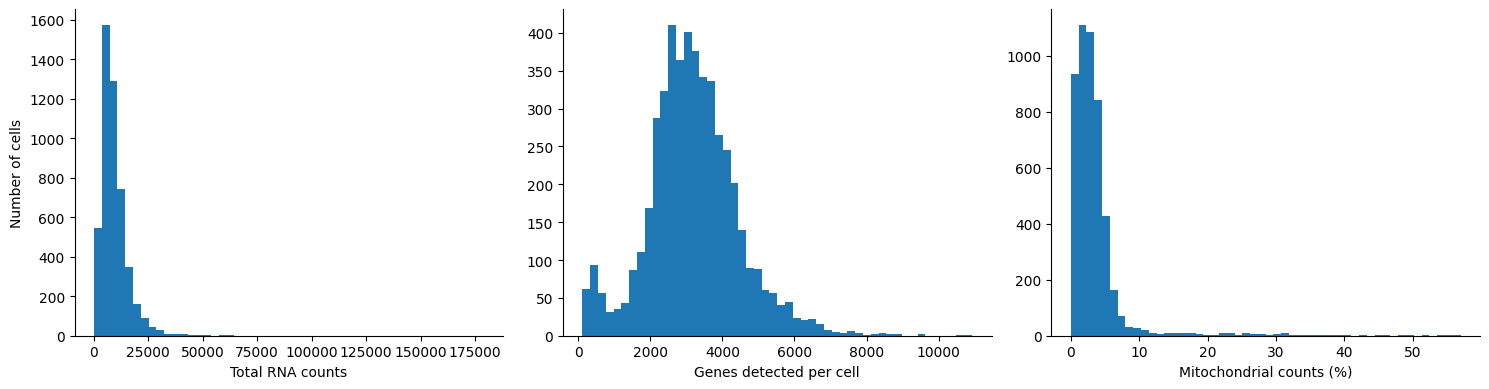

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rna.obs["total_counts"], bins=50)
axes[0].set_xlabel("Total RNA counts")
axes[0].set_ylabel("Number of cells")

axes[1].hist(rna.obs["n_genes_by_counts"], bins=50)
axes[1].set_xlabel("Genes detected per cell")

axes[2].hist(rna.obs["pct_counts_mt"], bins=50)
axes[2].set_xlabel("Mitochondrial counts (%)")

plt.tight_layout()
plt.show()

### Identify RNA QC outliers

I flag cells with unusually low or high library complexity using a median absolute deviation (MAD)-based rule. Cells with mitochondrial transcript fractions above 10% are also considered low quality, following the thresholds used in the official ATLAS tutorial.

In [15]:
def compute_outlier(adata, metric, nmads):
    values = adata.obs[metric]

    lower = np.median(values) - nmads * median_abs_deviation(values)
    upper = np.median(values) + nmads * median_abs_deviation(values)

    return (values < lower) | (values > upper)


rna.obs["outlier"] = (
    compute_outlier(rna, "log1p_total_counts", 5)
    | compute_outlier(rna, "log1p_n_genes_by_counts", 5)
    | (rna.obs["pct_counts_mt"] > 10)
)

print("RNA QC outliers:", rna.obs["outlier"].sum())
print("Cells passing RNA QC:", (~rna.obs["outlier"]).sum())
print(
    "Percent flagged:",
    round(100 * rna.obs["outlier"].mean(), 2)
)

RNA QC outliers: 282
Cells passing RNA QC: 4599
Percent flagged: 5.78


### ATAC quality-control metrics

For the scATAC-seq modality, I calculate per-cell accessibility metrics and the nucleosome signal. The nucleosome signal reflects the relative abundance of mono-nucleosomal versus nucleosome-free fragments and is commonly used to identify lower-quality ATAC libraries.

In [16]:
sc.pp.calculate_qc_metrics(
    atac,
    percent_top=None,
    log1p=False,
    inplace=True
)

mu.atac.tl.nucleosome_signal(
    atac,
    n=1_000_000
)

atac.obs[
    [
        "total_counts",
        "n_genes_by_counts",
        "nucleosome_signal",
    ]
].describe()

Reading Fragments: 100%|██████████| 1000000/1000000 [00:05<00:00, 192097.29it/s]


,total_counts,n_genes_by_counts,nucleosome_signal
count,4881.000000,4881.000000,4881.000000
mean,21008.623047,8115.156730,1.122587
std,16829.103516,5303.275252,0.478753
min,88.000000,45.000000,0.000000
25%,9206.000000,4150.000000,0.857143
50%,17920.000000,7455.000000,1.075472
75%,29015.000000,11330.000000,1.317073
max,318543.000000,57170.000000,8.000000


### Inspect nucleosome signal

I visualize the per-cell nucleosome signal before filtering. Following the official ATLAS tutorial, cells with a nucleosome signal greater than 2 are flagged as failing this ATAC quality-control criterion.

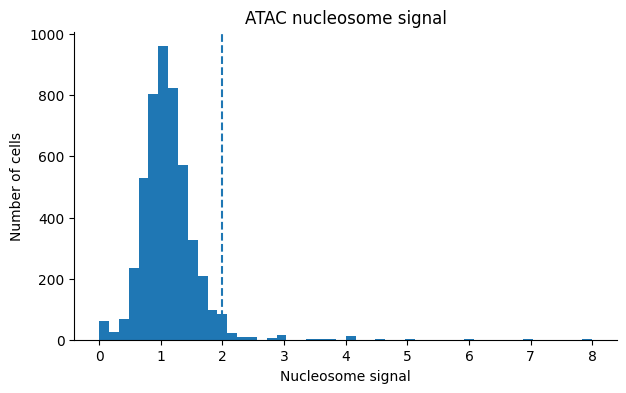

nuc_filter
NUC_PASS    4781
NUC_FAIL     100
Name: count, dtype: int64


In [17]:
nuc_threshold = 2

atac.obs["nuc_filter"] = np.where(
    atac.obs["nucleosome_signal"] > nuc_threshold,
    "NUC_FAIL",
    "NUC_PASS"
)

plt.figure(figsize=(7, 4))
plt.hist(atac.obs["nucleosome_signal"], bins=50)
plt.axvline(nuc_threshold, linestyle="--")
plt.xlabel("Nucleosome signal")
plt.ylabel("Number of cells")
plt.title("ATAC nucleosome signal")
plt.show()

print(atac.obs["nuc_filter"].value_counts())

### Summarize nucleosome QC

I count how many cells pass or fail the nucleosome-signal threshold to quantify the impact of this ATAC quality-control filter.

In [18]:
atac.obs["nuc_filter"].value_counts()

,count
nuc_filter,
NUC_PASS,4781
NUC_FAIL,100


### TSS enrichment

Transcription start site (TSS) enrichment measures whether ATAC-seq fragments are preferentially concentrated around gene promoters, as expected for high-quality chromatin-accessibility data. I calculate a per-cell TSS enrichment score using the gene coordinates defined above.

In [19]:
tss_enr = mu.atac.tl.tss_enrichment(
    atac,
    features=gene_coordinates,
    random_state=seed
)

atac.obs["tss_score"].describe()

Fetching Regions...: 100%|██████████| 2000/2000 [00:18<00:00, 106.72it/s]


,tss_score
count,4881.000000
mean,5.109827
std,9.541125
min,0.000000
25%,3.692528
50%,4.411049
75%,5.444069
max,576.856477


### Inspect TSS enrichment

I visualize the distribution of per-cell TSS enrichment scores. Following the official ATLAS tutorial, cells with TSS enrichment below 1.5 are considered low quality, while unusually high values above 15 are also treated as outliers.

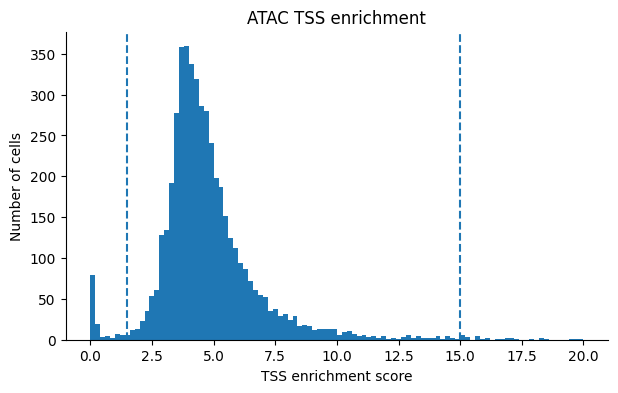

In [20]:
tss_min = 1.5
tss_max = 15

plt.figure(figsize=(7, 4))
plt.hist(atac.obs["tss_score"], bins=100, range=(0, 20))
plt.axvline(tss_min, linestyle="--")
plt.axvline(tss_max, linestyle="--")
plt.xlabel("TSS enrichment score")
plt.ylabel("Number of cells")
plt.title("ATAC TSS enrichment")
plt.show()

### Flag TSS quality-control failures

Cells with TSS enrichment below 1.5 are flagged as low quality. Extremely high TSS scores above 15 are also treated as outliers, matching the filtering logic used in the official ATLAS tutorial.

In [21]:
tss_threshold = 1.5

atac.obs["tss_filter"] = np.where(
    atac.obs["tss_score"] < tss_threshold,
    "TSS_FAIL",
    "TSS_PASS"
)

print(atac.obs["tss_filter"].value_counts())
print("\nCells with TSS score > 15:", (atac.obs["tss_score"] > 15).sum())

tss_filter
TSS_PASS    4757
TSS_FAIL     124
Name: count, dtype: int64

Cells with TSS score > 15: 58


### Define ATAC QC outliers

I combine the nucleosome-signal and TSS-enrichment criteria into a single ATAC quality-control flag. A cell is considered an ATAC outlier if it fails the minimum TSS threshold, has an unusually high TSS score, or fails the nucleosome-signal criterion.

In [22]:
atac.obs["outlier"] = (
    (atac.obs["tss_filter"] == "TSS_FAIL")
    | (atac.obs["tss_score"] > 15)
    | (atac.obs["nuc_filter"] == "NUC_FAIL")
)

print("ATAC QC outliers:", atac.obs["outlier"].sum())
print("Cells passing ATAC QC:", (~atac.obs["outlier"]).sum())
print(
    "Percent flagged:",
    round(100 * atac.obs["outlier"].mean(), 2)
)

ATAC QC outliers: 268
Cells passing ATAC QC: 4613
Percent flagged: 5.49


### Combine modalities and apply joint QC

Because ATLAS operates on paired multimodal data, I combine the RNA and ATAC `AnnData` objects into a single `MuData` container. I then retain only cells that pass quality control in **both** modalities.

In [25]:
joint_qc_pass = (
    ~mdata["rna"].obs["outlier"]
    & ~mdata["atac"].obs["outlier"]
)

mdata = mdata[joint_qc_pass, :].copy()

print("Cells before joint QC:", 4881)
print("Cells after joint QC:", mdata.n_obs)
print("Cells removed:", 4881 - mdata.n_obs)

Cells before joint QC: 4881
Cells after joint QC: 4351
Cells removed: 530


### Add cell-type annotations

I add the published cell-type annotations provided with the MultiVelo analysis. These labels are not used to construct the multimodal representation itself, but they provide biological context and are later used to restrict the trajectory analysis to relevant developmental populations.

In [26]:
annotations = pd.read_csv(
    annotation_path,
    sep="\t",
    header=0,
    index_col=0
)

print("Annotation table shape:", annotations.shape)
print("Annotation columns:", annotations.columns.tolist())

annotations.head()

Annotation table shape: (4423, 1)
Annotation columns: ['celltype']


,celltype
AACCTTAAGTAGCGGG-1,"RG, Astro, OPC"
AACAGCAAGTTATCCT-1,Subplate
AACTAGCTCAATGTGC-1,IPC
AAAGGCTCACCTGGTG-1,Ependymal cells
AACTAGCTCAGCACGC-1,"RG, Astro, OPC"


### Attach cell-type labels

I join the published MultiVelo cell-type annotations to the QC-filtered multimodal object using the cell barcodes as identifiers. Because the annotation table and the filtered dataset do not contain exactly the same cells, I also check how many retained cells have an available annotation.

In [27]:
mdata.obs = mdata.obs.join(annotations)

print("Cells after joint QC:", mdata.n_obs)
print("Cells with annotation:", mdata.obs["celltype"].notna().sum())
print("Cells without annotation:", mdata.obs["celltype"].isna().sum())

mdata.obs["celltype"].value_counts(dropna=False)

Cells after joint QC: 4351
Cells with annotation: 4173
Cells without annotation: 178


,count
celltype,
Upper Layer,1021
Deeper Layer,720
V-SVZ,673
"RG, Astro, OPC",528
Interneurons1,293
Interneurons2,250
Ependymal cells,197
IPC,193
NaN,178


### Restrict to developmental lineages

The ATLAS tutorial focuses on cortical developmental trajectories. I therefore remove cell populations that are not part of the developmental lineages being modeled, including interneurons, Cajal-Retzius cells, microglia, and cells without an annotation.

In [28]:
non_developing_clusters = [
    "Cajal-Retzius",
    "Interneurons1",
    "Interneurons2",
    "Interneurons3",
    "Microglia",
]

developmental_mask = (
    mdata.obs["celltype"].notna()
    & ~mdata.obs["celltype"].isin(non_developing_clusters)
)

mdata = mdata[developmental_mask, :].copy()

print("Cells retained for trajectory analysis:", mdata.n_obs)
print("\nCell-type composition:")
print(mdata.obs["celltype"].value_counts())

Cells retained for trajectory analysis: 3486

Cell-type composition:
celltype
Upper Layer        1021
Deeper Layer        720
V-SVZ               673
RG, Astro, OPC      528
Ependymal cells     197
IPC                 193
Subplate            154
Name: count, dtype: int64


## 6. ATLAS multimodal preprocessing

ATLAS converts the scATAC-seq fragment data into gene-activity scores and integrates these with the paired scRNA-seq measurements.

The preprocessing workflow performs normalization and dimensionality reduction separately for the RNA and gene-activity modalities, constructs modality-specific nearest-neighbor graphs, and combines them into a weighted nearest-neighbor (WNN) graph. This joint graph represents cellular similarity using information from both transcriptional state and chromatin accessibility.

In [29]:
knn_rna = 15
knn_act = 15
wnn = None

n_pcs_rna = 20
n_pcs_act = 10

mdata = atlas.pp.preprocessing(
    mudata=mdata,
    n_pcs_rna=n_pcs_rna,
    n_pcs_act=n_pcs_act,
    knn_rna=knn_rna,
    knn_act=knn_act,
    n_neighbors=wnn,
    features=gene_coordinates,
)

100%|██████████| 32195/32195 [02:32<00:00, 211.09it/s]


### Inspect the preprocessed multimodal object

I inspect the output of ATLAS preprocessing to confirm that the gene-activity modality and multimodal neighbor graph were created successfully.

In [30]:
print(mdata)

print("\nModalities:", list(mdata.mod.keys()))
print("Top-level embeddings:", list(mdata.obsm.keys()))
print("Top-level graphs:", list(mdata.obsp.keys()))

MuData object with n_obs × n_vars = 3486 × 64480
  obs:	'celltype'
  uns:	'wnn', 'umap'
  obsm:	'atac', 'X_umap'
  obsp:	'wnn_distances', 'wnn_connectivities'
  2 modalities
    rna:	3486 × 32285
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier'
      var:	'gene_ids', 'feature_types', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      uns:	'pca', 'neighbors'
      obsm:	'X_pca'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    activity:	3486 × 32195
      obs:	'n_genes_by_counts', 'total_counts', 'nucleosome_signal', 'nuc_filter', 'tss_score', 'tss_filter', 'outlier'
      var:	'Chro

### Inspect variance explained by gene-activity PCs

I examine the proportion of variance explained by each principal component in the ATAC-derived gene-activity representation. This provides a diagnostic view of the dimensionality reduction used to construct the activity-based nearest-neighbor graph.

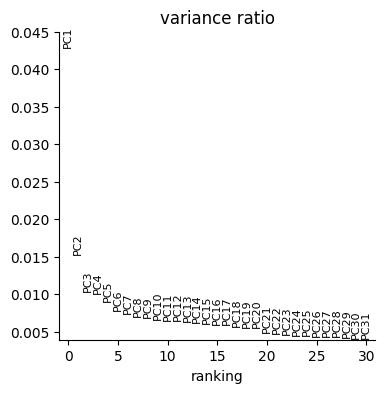

In [31]:
sc.pl.pca_variance_ratio(mdata["activity"])

### Visualize the integrated multimodal embedding

I visualize the UMAP computed from the ATLAS weighted nearest-neighbor graph and color cells by their published cell-type annotations. This shows whether the integrated RNA and chromatin-accessibility representation recapitulates the expected developmental structure.

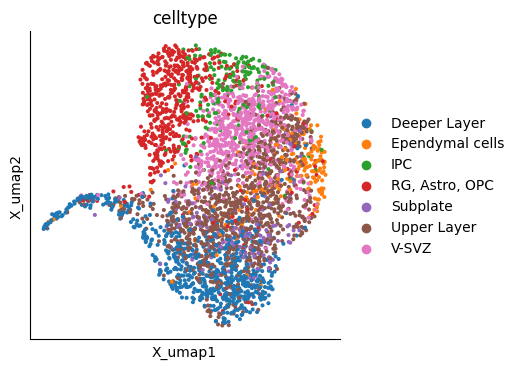

In [32]:
mu.pl.embedding(
    mdata,
    basis="X_umap",
    color=["celltype"]
)

### Save the preprocessed multimodal dataset

I save the fully preprocessed `MuData` object so that subsequent trajectory-inference tutorials can start from this checkpoint without repeating data download, quality control, gene-activity calculation, and multimodal integration.

The resulting `.h5mu` file is a large analysis artifact and should not be committed to GitHub.

In [33]:
output_path = os.path.join(data_path, "data.h5mu")

mdata.write(output_path)

print("Saved to:", output_path)
print("File size (GB):", round(os.path.getsize(output_path) / 1e9, 2))

Saved to: /content/data/data.h5mu
File size (GB): 0.24
